## What We Did in This Notebook

So this notebook is all about analyzing the career trajectories of junior researchers who won awards at top conferences. We started by loading matched pairs of treated (award winners) and control authors, then fetched detailed profiles for the controls from the OpenAlex API. After combining the data, we parsed yearly publication and citation counts to build trajectories relative to the award year. We crunched some stats, plotted citation and publication trends with differences between treated and controls, and even ran a quick regression to check balance. Basically, exploring if winning early awards boosts long-term impact!

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import time

# Load data
matched = pd.read_csv('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\matched\\matched_pairs_clean.csv')
juniors = pd.read_csv('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\matched\\junior_authors_all_conferences.csv')
juniors = juniors.merge(matched[['treated_id','control_id']], 
                       left_on='author_id', right_on='treated_id', how='inner')

print(f"Matched juniors: {len(juniors)}")
print(f"Control IDs to fetch: {matched['control_id'].nunique()}")

# Fetch profiles for controls (reuse junior_profiles_all.csv for treated)
control_profiles = []
processed = set(juniors['author_id'].tolist())

for _, row in matched.iterrows():
    author_id = row['control_id']
    if pd.isna(author_id) or author_id in processed:
        continue



    url = f"https://api.openalex.org/authors/{author_id.split('/')[-1]}"
    try:
        r = requests.get(url, params={'mailto': 'shaheryar.4822@student.uu.se'}, timeout=10)
        if r.status_code == 200:
            profile = r.json()
            summary = profile.get('summary_stats', {})
            control_profiles.append({
                'author_id'         : author_id,
                'author_name'       : profile.get('display_name'),
                'works_count'       : profile.get('works_count', 0),
                'cited_by_count'    : profile.get('cited_by_count', 0),
                'counts_by_year'    : json.dumps(profile.get('counts_by_year', [])),
                'award_year'        : row['award_year'],
                'conference'        : row['conference'],
                'treatment'         : 0,  # control
            })
        time.sleep(0.12)
    except:
        pass

# Load junior profiles + add treatment flag
junior_profiles = pd.read_csv('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\profiles\\junior_profiles_all.csv')
junior_profiles['treatment'] = 1

# Combine
all_profiles = pd.concat([
    junior_profiles[['author_id','author_name','works_count','cited_by_count','counts_by_year','award_year','conference','treatment']],
    pd.DataFrame(control_profiles)
], ignore_index=True)

all_profiles.to_csv('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\profiles\\all_matched_profiles.csv', index=False)
print(f"✅ All profiles: {len(all_profiles)}")


Matched juniors: 345
Control IDs to fetch: 345
✅ All profiles: 946


In [2]:
def parse_cby(raw):
    if pd.isna(raw): return []
    try: return json.loads(raw.replace("'", '"'))
    except: return []

# Extract relative-year metrics
all_trajectories = []
for _, row in all_profiles.iterrows():
    cby = parse_cby(row['counts_by_year'])
    aw_year = row['award_year']
    for e in cby:
        yr = e.get('year')
        if yr and abs(yr - aw_year) <= 5:
            all_trajectories.append({
                'rel_year'   : yr - aw_year,
                'works'      : e.get('works_count', 0),
                'citations'  : e.get('cited_by_count', 0),
                'treatment'  : row['treatment'],
                'conference' : row['conference'],
            })

trajectories = pd.DataFrame(all_trajectories)
print(f"Trajectory rows: {len(trajectories):,}")
print(f"By treatment: {trajectories['treatment'].value_counts().to_dict()}")


Trajectory rows: 7,278
By treatment: {1: 3850, 0: 3428}


## Trajectory Summary with Bootstrap Confidence Intervals

Instead of just plotting the raw median per year, we also compute **95% bootstrap confidence intervals** around each median.

### Why bootstrap?
We use the **median** (rather than the mean) as our central tendency measure because citation and publication counts are highly right-skewed — a handful of prolific authors would otherwise dominate the average. The median is more robust to those outliers.

The downside of the median is that it doesn't have a simple closed-form standard error formula like the mean does. **Bootstrapping** is the standard solution: we repeatedly resample the group (with replacement) 1 000 times, compute the median each time, and take the 2.5th and 97.5th percentiles of those 1 000 medians as our confidence interval bounds.

This gives us an honest picture of how uncertain each median estimate is, accounting for sample size differences across years and groups. The resulting `_lo` / `_hi` columns are then used to draw **shaded bands** around the trend lines, and a **shaded band** around the treated−control difference line.

In [3]:
import numpy as np

N_BOOT = 1000
rng = np.random.default_rng(42)

def bootstrap_median_ci(vals, n_boot=N_BOOT, ci=95):
    """Return (median, lower, upper) via bootstrap resampling."""
    vals = np.asarray(vals)
    boots = rng.choice(vals, size=(n_boot, len(vals)), replace=True)
    medians = np.median(boots, axis=1)
    lo = np.percentile(medians, (100 - ci) / 2)
    hi = np.percentile(medians, 100 - (100 - ci) / 2)
    return np.median(vals), lo, hi

rows = []
for (rel_year, treatment), grp in trajectories.groupby(['rel_year', 'treatment']):
    med_c, lo_c, hi_c = bootstrap_median_ci(grp['citations'].values)
    med_w, lo_w, hi_w = bootstrap_median_ci(grp['works'].values)
    rows.append(dict(
        rel_year=rel_year, treatment=treatment,
        med_cites=med_c, cites_lo=lo_c, cites_hi=hi_c,
        med_works=med_w, works_lo=lo_w, works_hi=hi_w,
    ))

traj_summary = pd.DataFrame(rows)


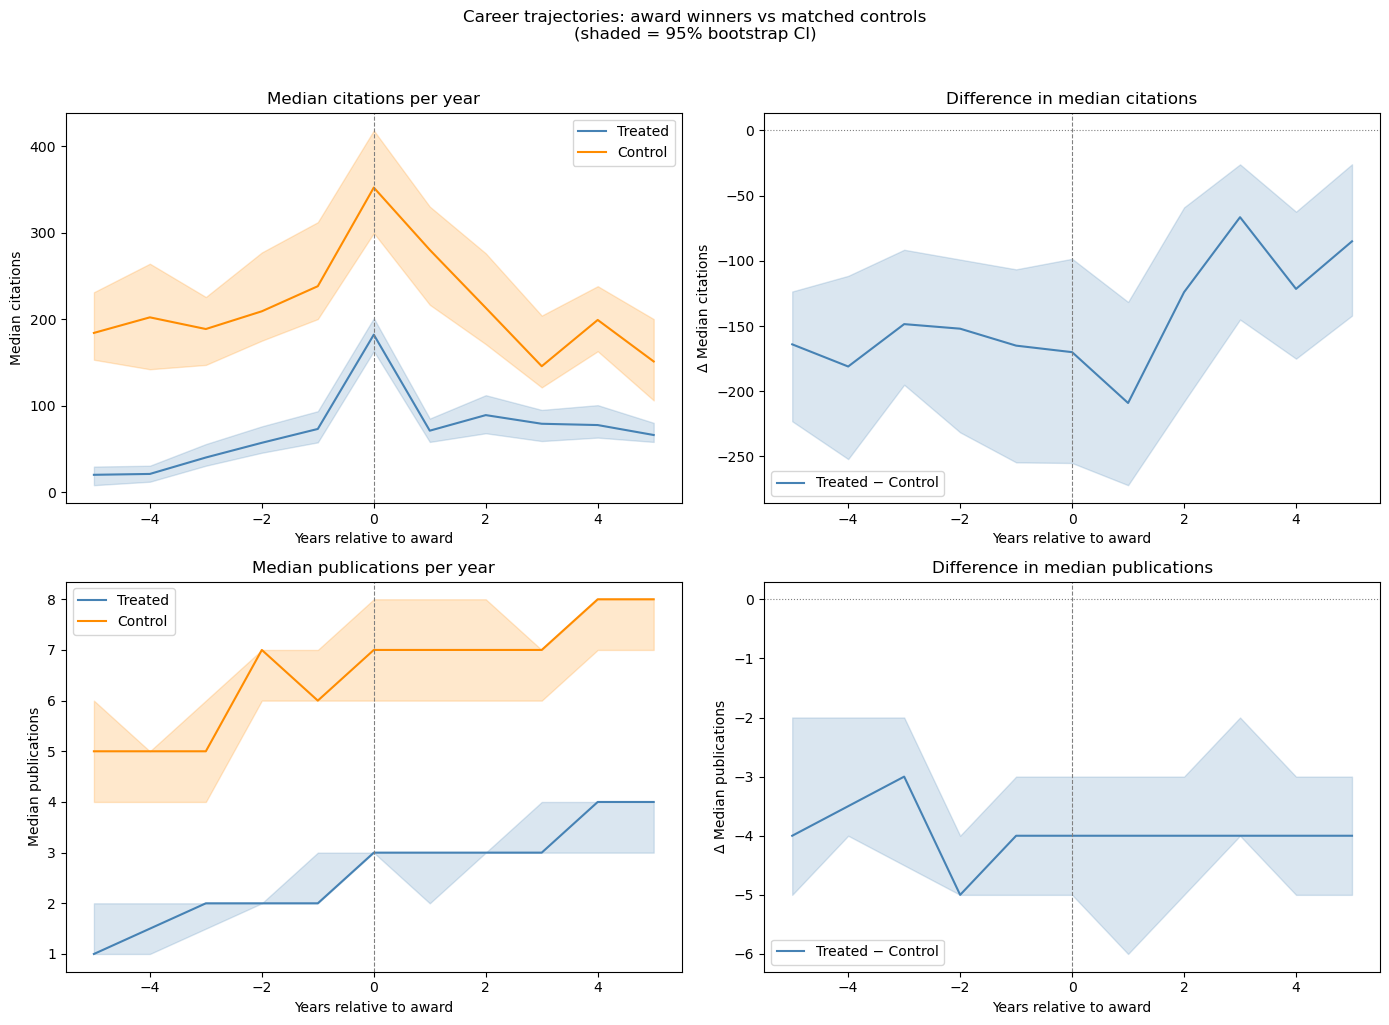

In [4]:
import matplotlib.pyplot as plt

treated  = traj_summary[traj_summary['treatment'] == 1].sort_values('rel_year')
controls = traj_summary[traj_summary['treatment'] == 0].sort_values('rel_year')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
years = treated['rel_year'].values

# ── Citations trend ──────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(years, treated['med_cites'],  color='steelblue', label='Treated')
ax.fill_between(years, treated['cites_lo'], treated['cites_hi'],
                color='steelblue', alpha=0.2)
ax.plot(years, controls['med_cites'], color='darkorange', label='Control')
ax.fill_between(years, controls['cites_lo'], controls['cites_hi'],
                color='darkorange', alpha=0.2)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Median citations per year')
ax.set_xlabel('Years relative to award')
ax.set_ylabel('Median citations')
ax.legend()

# ── Citations difference ─────────────────────────────────────────────────────
ax = axes[0, 1]
diff_c    = treated['med_cites'].values  - controls['med_cites'].values
diff_c_lo = treated['cites_lo'].values   - controls['cites_hi'].values
diff_c_hi = treated['cites_hi'].values   - controls['cites_lo'].values
ax.plot(years, diff_c, color='steelblue', label='Treated − Control')
ax.fill_between(years, diff_c_lo, diff_c_hi, color='steelblue', alpha=0.2)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linestyle=':',  linewidth=0.8)
ax.set_title('Difference in median citations')
ax.set_xlabel('Years relative to award')
ax.set_ylabel('Δ Median citations')
ax.legend()

# ── Publications trend ───────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(years, treated['med_works'],  color='steelblue', label='Treated')
ax.fill_between(years, treated['works_lo'], treated['works_hi'],
                color='steelblue', alpha=0.2)
ax.plot(years, controls['med_works'], color='darkorange', label='Control')
ax.fill_between(years, controls['works_lo'], controls['works_hi'],
                color='darkorange', alpha=0.2)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Median publications per year')
ax.set_xlabel('Years relative to award')
ax.set_ylabel('Median publications')
ax.legend()

# ── Publications difference ──────────────────────────────────────────────────
ax = axes[1, 1]
diff_w    = treated['med_works'].values  - controls['med_works'].values
diff_w_lo = treated['works_lo'].values   - controls['works_hi'].values
diff_w_hi = treated['works_hi'].values   - controls['works_lo'].values
ax.plot(years, diff_w, color='steelblue', label='Treated − Control')
ax.fill_between(years, diff_w_lo, diff_w_hi, color='steelblue', alpha=0.2)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linestyle=':',  linewidth=0.8)
ax.set_title('Difference in median publications')
ax.set_xlabel('Years relative to award')
ax.set_ylabel('Δ Median publications')
ax.legend()

plt.suptitle('Career trajectories: award winners vs matched controls\n(shaded = 95% bootstrap CI)', y=1.02)
plt.tight_layout()
plt.show()


Top-Right — Difference in Citations (Treated − Control)
This is the key DiD panel. The line is always negative, meaning treated authors always have fewer citations than controls.

**The controls dominating on both metrics is a red flag about covariate imbalance, our treated group (junior award winners) are being compared to more senior/prolific authors.**